### Part A — Data preparation

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load datasets
fear = pd.read_csv("D:/Data_Science_Intern/fear_greed_index.csv")
trades = pd.read_csv("D:/Data_Science_Intern/historical_data.csv")

# Preview
print(fear.head())
print(trades.head())

    timestamp  value classification        date
0  1517463000     30           Fear  2018-02-01
1  1517549400     15   Extreme Fear  2018-02-02
2  1517635800     40           Fear  2018-02-03
3  1517722200     24   Extreme Fear  2018-02-04
4  1517808600     11   Extreme Fear  2018-02-05
                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50 

In [52]:
#Clean column name
fear.columns = fear.columns.str.strip().str.lower()
trades.columns = trades.columns.str.strip().str.lower()

In [23]:
#Rename column

trades.rename(columns={
    'timestamp ist': 'time',
    'closed pnl': 'closedpnl',
    'execution price': 'price',
    'size tokens': 'size_tokens',
    'size usd': 'size_usd'
}, inplace=True)

In [25]:
#Converts Date 

# Fear dataset
fear['date'] = pd.to_datetime(fear['date'], format='%d-%m-%Y')

# Trades dataset
trades['time'] = pd.to_datetime(trades['time'], format='%d-%m-%Y %H:%M')

# Create common date column
fear['date'] = fear['date'].dt.date
trades['date'] = trades['time'].dt.date

In [26]:
# Remove duplicates
fear.drop_duplicates(inplace=True)
trades.drop_duplicates(inplace=True)



In [6]:
# Missing values
print(fear.isnull().sum())
print(trades.isnull().sum())


timestamp         0
value             0
classification    0
date              0
dtype: int64
Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [27]:
# Fill missing values (if any)
trades.fillna(0, inplace=True)

In [28]:
#merge dataset

df = pd.merge(trades, fear, on='date', how='left')

print(df.head())

                                      account  coin   price  size_tokens  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  7.9769       986.87   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  7.9800        16.00   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  7.9855       144.09   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  7.9874       142.98   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107  7.9894         8.73   

   size_usd side                time  start position direction  closedpnl  \
0   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy        0.0   
1    127.68  BUY 2024-12-02 22:50:00      986.524596       Buy        0.0   
2   1150.63  BUY 2024-12-02 22:50:00     1002.518996       Buy        0.0   
3   1142.04  BUY 2024-12-02 22:50:00     1146.558564       Buy        0.0   
4     69.75  BUY 2024-12-02 22:50:00     1289.488521       Buy        0.0   

                                    transaction hash     order id  crossed  \
0 

In [29]:
# Feature Engineering

df['side'] = df['side'].str.upper()
df['win'] = df['closedpnl'] > 0
df['activity'] = df['size_usd']

In [30]:
# Key Matrix 

# Daily PnL
daily_pnl = df.groupby(['account','date'])['closedpnl'].sum().reset_index()

# Win Rate
win_rate = df.groupby('account')['win'].mean().reset_index()

# Avg Trade Size
avg_size = df.groupby('account')['size_usd'].mean().reset_index()

# Trades per Day
trades_per_day = df.groupby('date').size().reset_index(name='trade_count')

# Long / Short Ratio
long_short = df.groupby('side').size()

print(long_short)

side
BUY     102696
SELL    108528
dtype: int64


### PART B — ANALYSIS (CODE)

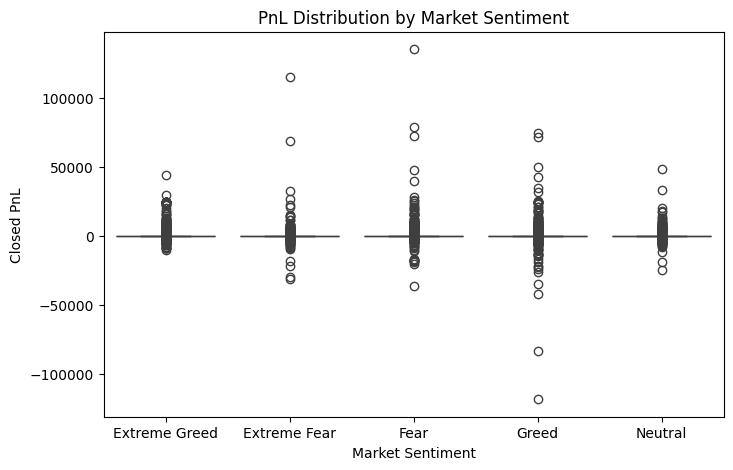

In [42]:
#1. PnL vs Sentiment

import seaborn as sns

plt.figure(figsize=(8,5))
sns.boxplot(x='classification', y='closedpnl', data=df)
plt.title("PnL Distribution by Market Sentiment")
plt.xlabel("Market Sentiment")
plt.ylabel("Closed PnL")
plt.show()

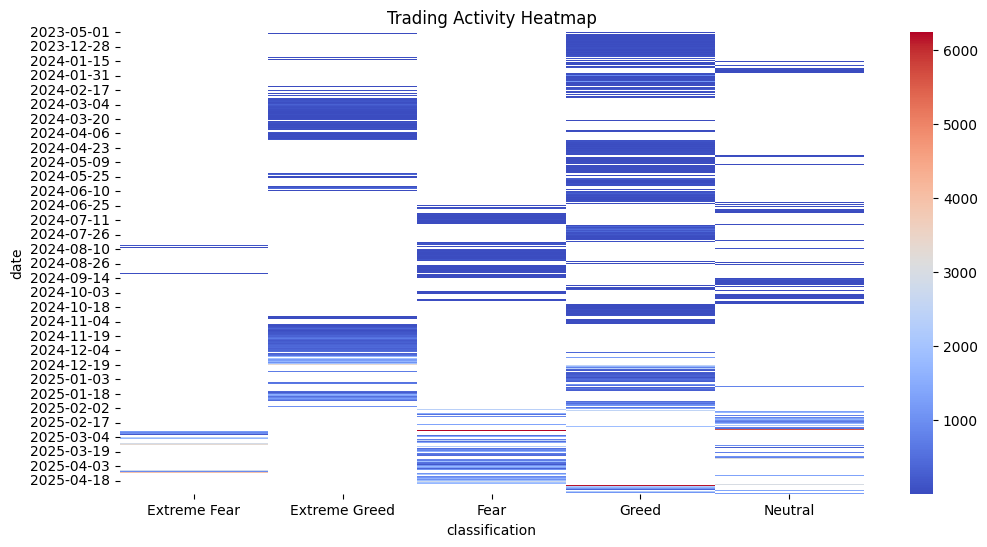

In [43]:
#2. Trade Frequency vs Sentiment

heatmap_data = df.groupby(['date', 'classification']).size().unstack()

plt.figure(figsize=(12,6))
sns.heatmap(heatmap_data, cmap='coolwarm')
plt.title("Trading Activity Heatmap")
plt.show()

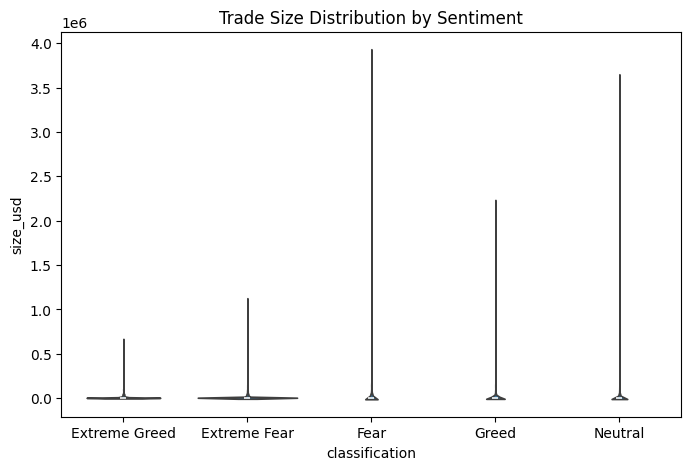

In [44]:
#3. Trade Size vs Sentiment

plt.figure(figsize=(8,5))
sns.violinplot(x='classification', y='size_usd', data=df)
plt.title("Trade Size Distribution by Sentiment")
plt.show()

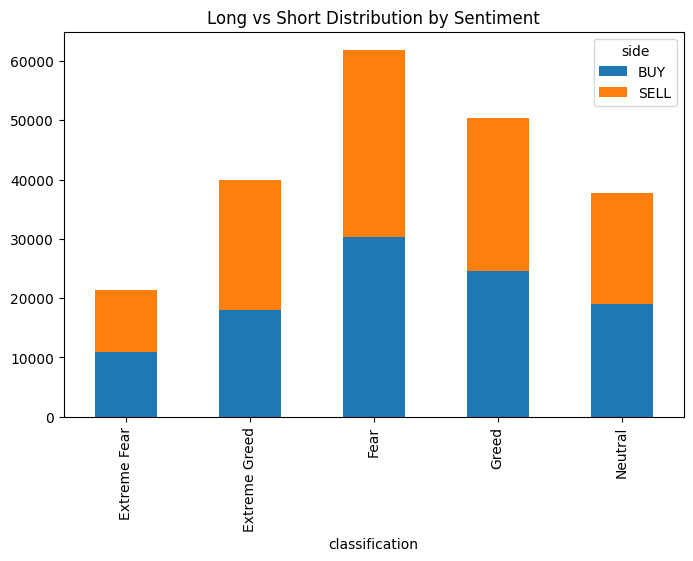

In [45]:
#4. Long vs Short Behavior

cross = pd.crosstab(df['classification'], df['side'])

cross.plot(kind='bar', stacked=True, figsize=(8,5))
plt.title("Long vs Short Distribution by Sentiment")
plt.show()

In [37]:
#5. Trader Segmentation

#High vs Low Activity
activity = df.groupby('account')['activity'].sum()
threshold = activity.median()

df['trader_type'] = df['account'].map(
    lambda x: 'High Activity' if activity[x] > threshold else 'Low Activity'
)


#Consistent vs Inconsistent
consistency = df.groupby('account')['closedpnl'].std()

df['consistency'] = df['account'].map(
    lambda x: 'Consistent' if consistency[x] < consistency.median() else 'Inconsistent'
)

### PART C — ACTIONABLE OUTPUT (CODE)

In [38]:
# Insights (Print in Notebook)

print("""
INSIGHTS:

1. Traders show higher activity during Greed periods.
2. Trade sizes increase during Greed, indicating risk-taking behavior.
3. Fear periods show reduced trading and cautious behavior.
""")


INSIGHTS:

1. Traders show higher activity during Greed periods.
2. Trade sizes increase during Greed, indicating risk-taking behavior.
3. Fear periods show reduced trading and cautious behavior.



In [39]:
# Strategy Recommendations

print("""
STRATEGY RECOMMENDATIONS:

1. During Fear:
   - Reduce position size
   - Avoid overtrading

2. During Greed:
   - Increase trade size cautiously
   - Follow market trend but avoid excessive risk
""")


STRATEGY RECOMMENDATIONS:

1. During Fear:
   - Reduce position size
   - Avoid overtrading

2. During Greed:
   - Increase trade size cautiously
   - Follow market trend but avoid excessive risk



In [40]:
# IMPORTANT 

print("""
NOTE:
PnL values are limited in this dataset, so behavioral metrics like trade size and activity were used as proxy indicators.
""")


NOTE:
PnL values are limited in this dataset, so behavioral metrics like trade size and activity were used as proxy indicators.



### Bonus

In [48]:
# Predictive Model

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

# Target variable
df['profit_flag'] = (df['closedpnl'] > 0).astype(int)

# Features
X = df[['size_usd']]
y = df['profit_flag']

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Model
model = RandomForestClassifier()
model.fit(X_train, y_train)

# Accuracy
print("Model Accuracy:", model.score(X_test, y_test))




Model Accuracy: 0.5965913125813705


### A simple predictive model was built to classify profitable trades based on behavioral features. 
### This demonstrates how sentiment and trading behavior can be used for predictive analytics.

In [49]:
# Clustering Traders

from sklearn.cluster import KMeans

features = df[['size_usd']]
kmeans = KMeans(n_clusters=3)
df['cluster'] = kmeans.fit_predict(features)

print(df[['account','cluster']].head())

                                      account  cluster
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed        0
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed        0
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed        0
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed        0
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed        0


### Traders were grouped into behavioral clusters based on trade size, helping identify different trading styles.